# EDA

This file is cleaning the data befoe exploring the time series. it follows the following steps:
- Step 1: Checking for Missing Data
- Step 2: Handling Outliers
- Step 3: Fill missing dates with zero sales
- Step 4: Feature Engineering: turning a date into useful signals
- Step 5: Visualizing Time-Series Data
- Step 6: Examining the Impact of Holidays
- Step 7: Analyzing Perishable Items


**Additional Notes**

>Wages in the public sector are paid every two weeks on the **15** th and on the **last day of the month**. Supermarket sales could be affected by this.

>A magnitude 7.8 **earthquake** struck Ecuador on **April 16, 2016**. People rallied in relief efforts donating water and other first need products which greatly affected supermarket sales for several weeks after the earthquake.

## Libraries

Installing the needed libraries

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

## Setting Variables

In [82]:
random_seed = 42

## Checking for Missing Data, Handlining Outliers and Filling missing values

Loading and checking for missing data in each file
- holiday.csv
- oil.csv
- stores.csv
- timeseries.csv


In [83]:
# define path
path = "../data/raw/"

### stores.csv

In [84]:
# stores data
stores_df = pd.read_csv(path + "stores.csv")
print('Stores DataFrame:')
print(stores_df.shape)
print(f"Na values in stores_df: \n{stores_df.isna().sum()}")
print(f"Statistics of stores_df: \n{stores_df.describe()}")

Stores DataFrame:
(54, 3)
Na values in stores_df: 
store_nbr    0
city         0
region       0
dtype: int64
Statistics of stores_df: 
       store_nbr
count  54.000000
mean   27.500000
std    15.732133
min     1.000000
25%    14.250000
50%    27.500000
75%    40.750000
max    54.000000


**Importend:** Need to use this to find the right holidays. **store_nbr 44**

In [85]:
# print store_nbr 44 information
print(f"Information for store_nbr 44: \n{stores_df[stores_df['store_nbr'] == 44]}")
city = stores_df[stores_df['store_nbr'] == 44]['city'].values[0]
region = stores_df[stores_df['store_nbr'] == 44]['region'].values[0]

Information for store_nbr 44: 
    store_nbr   city     region
43         44  Quito  Pichincha


### holidays.csv

In [86]:
# holiday data
holiday_df = pd.read_csv(path + "holidays.csv")
print('Holiday DataFrame:')
print(holiday_df.shape)
print(f"Na values in holiday_df: \n{holiday_df.isna().sum()}")
print(f"Statistics of holiday_df: \n{holiday_df.describe()}")

Holiday DataFrame:
(350, 4)
Na values in holiday_df: 
date           0
locale         0
locale_name    0
description    0
dtype: int64
Statistics of holiday_df: 
              date    locale locale_name description
count          350       350         350         350
unique         312         3          24         103
top     2014-06-25  National     Ecuador    Carnaval
freq             4       174         174          10


> Filter the hoildays to only have all national holidays + all regional holidays from Pichincha + all local hoildays from Quito

In [87]:
def holiday_selection(store_nbr, stores_df, holiday_df):
    """
    This function selects the relevant holidays for a given store based on its city and region.
    
    Parameters:
    - store_nbr: The store number for which to select holidays.
    - stores_df: DataFrame containing store information.
    - holiday_df: DataFrame containing holiday information.
    
    Returns:
    - A DataFrame containing the relevant holidays for the specified store.
    """
    # Get city and region for the specified store
    store_info = stores_df[stores_df['store_nbr'] == store_nbr]
    if store_info.empty:
        raise ValueError(f"Store number {store_nbr} not found in stores_df.")
    
    city = store_info['city'].values[0]
    region = store_info['region'].values[0]
    
    # Select holidays relevant to the store
    relevant_holidays = holiday_df[
        (holiday_df['locale_name'] == city) | 
        (holiday_df['locale_name'] == region) | 
        (holiday_df['locale'] == 'National')
    ]
    
    return relevant_holidays

holidays_store_44_df = holiday_selection(44, stores_df, holiday_df)
print(f"Holiday data for store_nbr 44: \n{holidays_store_44_df.shape}")
holidays_store_44_df.to_csv("../data/procesed/holidays.csv")

Holiday data for store_nbr 44: 
(187, 4)


### oil.csv

In [88]:
# oil data
oil_df = pd.read_csv(path + "oil.csv")
print('Oil DataFrame:')
print(oil_df.shape)
print(f"Na values in oil_df: \n{oil_df.isna().sum()}")
print(f"Statistics of oil_df: \n{oil_df.describe()}")

Oil DataFrame:
(1218, 2)
Na values in oil_df: 
date           0
dcoilwtico    43
dtype: int64
Statistics of oil_df: 
        dcoilwtico
count  1175.000000
mean     67.714366
std      25.630476
min      26.190000
25%      46.405000
50%      53.190000
75%      95.660000
max     110.620000


> Fill the NaN with value before ffill() and the first value with the value after bfill()

**Important:** make sure time series is sorted correctly.

In [89]:
# sort by date
oil_df['date'] = pd.to_datetime(oil_df['date'])
oil_df = oil_df.sort_values('date')

# set date as index
oil_df.set_index('date', inplace=True)

# ffill missing values
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].ffill()
# bfill missing values to get the first value in the dataset
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].bfill()

# check for remaining missing values
print(f"Na values in oil_df after filling: \n{oil_df.isna().sum()}")

Na values in oil_df after filling: 
dcoilwtico    0
dtype: int64


> Check if date values are missing

In [90]:
# create a complete date range from the minimum to maximum date in the oil_df
dates = pd.date_range(start=oil_df.index.min(), end=oil_df.index.max(), freq='D')
# print difference between the complete date range and the existing dates in oil_df
print(f"Missing dates in oil_df: \n{dates.difference(oil_df.index)}")

# reindex oil_df to the complete date range, filling missing dates with NaN
oil_df = oil_df.reindex(dates)
# ffill missing values again to fill the newly introduced NaN values for missing dates
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].ffill()
# bfill missing values to get the first value in the dataset if the first date was missing
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].bfill()

# check for remaining missing values after reindexing
print(f"Na values in oil_df after reindexing and filling: \n{oil_df.isna().sum()}")

Missing dates in oil_df: 
DatetimeIndex(['2013-01-05', '2013-01-06', '2013-01-12', '2013-01-13',
               '2013-01-19', '2013-01-20', '2013-01-26', '2013-01-27',
               '2013-02-02', '2013-02-03',
               ...
               '2017-07-29', '2017-07-30', '2017-08-05', '2017-08-06',
               '2017-08-12', '2017-08-13', '2017-08-19', '2017-08-20',
               '2017-08-26', '2017-08-27'],
              dtype='datetime64[ns]', length=486, freq=None)
Na values in oil_df after reindexing and filling: 
dcoilwtico    0
dtype: int64


### timeseries.csv

In [91]:
# timeseries data
timeseries_df = pd.read_csv(path + "timeseries.csv")
print('Timeseries DataFrame:')
print(timeseries_df.shape)
print(f"Na values in timeseries_df: \n{timeseries_df.isna().sum()}")
print(f"Statistics of timeseries_df: \n{timeseries_df.describe()}")

Timeseries DataFrame:
(452, 2)
Na values in timeseries_df: 
date          0
unit_sales    0
dtype: int64
Statistics of timeseries_df: 
        unit_sales
count   452.000000
mean    480.090708
std     170.839776
min       4.000000
25%     358.000000
50%     445.500000
75%     578.250000
max    1203.000000


In [92]:
# sort by date
timeseries_df['date'] = pd.to_datetime(timeseries_df['date'])
timeseries_df = timeseries_df.sort_values('date')

# set date as index
timeseries_df.set_index('date', inplace=True)

> checking for missing values.

In [93]:
# create a complete date range from the minimum to maximum date in the oil_df
dates_ts = pd.date_range(start=timeseries_df.index.min(), end=timeseries_df.index.max(), freq='D')
# print difference between the complete date range and the existing dates in timeseries_df
print(f"Missing dates in timeseries_df: \n{dates_ts.difference(timeseries_df.index)}")

# reindex timeseries_df to the complete date range, filling missing dates with NaN
timeseries_df = timeseries_df.reindex(dates_ts)
# ffill missing values again to fill the newly introduced NaN values for missing dates
timeseries_df['unit_sales'] = timeseries_df['unit_sales'].ffill()
# bfill missing values to get the first value in the dataset if the first date was missing
timeseries_df['unit_sales'] = timeseries_df['unit_sales'].bfill()

# check for remaining missing values after reindexing
print(f"Na values in timeseries_df after reindexing and filling: \n{timeseries_df.isna().sum()}")

Missing dates in timeseries_df: 
DatetimeIndex(['2013-12-25', '2014-01-01'], dtype='datetime64[ns]', freq=None)
Na values in timeseries_df after reindexing and filling: 
unit_sales    0
dtype: int64


> checking for outliers.

In [94]:
# check for nagative unit_sales values
negative_sales = timeseries_df[timeseries_df['unit_sales'] < 0]
print(f"Negative unit_sales values: \n{len(negative_sales)}")

Negative unit_sales values: 
0


In [95]:
# check for outliers in unit_sales via z-score
timeseries_df['unit_sales_z'] = (timeseries_df['unit_sales'] - timeseries_df['unit_sales'].mean()) / (timeseries_df['unit_sales'].std() if timeseries_df['unit_sales'].std() != 0 else 1) # to avoid division by zero in case of zero standard deviation
threshold = 3
outliers = timeseries_df[(-(threshold) > np.abs(timeseries_df['unit_sales_z'])) | (np.abs(timeseries_df['unit_sales_z']) > threshold)]
print(f"Outliers in unit_sales (z-score < {threshold}): \n{len(outliers)}")

Outliers in unit_sales (z-score < 3): 
3


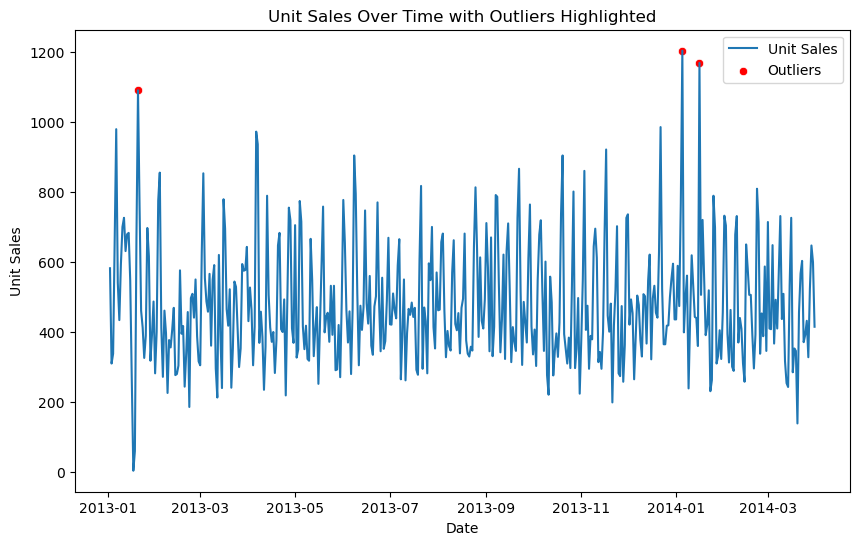

In [96]:
# plotting outliers
plt.figure(figsize=(10, 6))
sns.lineplot(data=timeseries_df, x=timeseries_df.index, y='unit_sales', label='Unit Sales')
sns.scatterplot(data=outliers, x=outliers.index, y='unit_sales', color='red', label='Outliers')
plt.title('Unit Sales Over Time with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()

> Keep the outliers in mind. Maybe they are explained through hoildays.

## Feature Engineering

Turning data into usefull signals.

### year, month, day, day_of_week, weekend Signal

In [97]:
# create temporary date columns for feature engineering
timeseries_df['dates'] = timeseries_df.index

# Split the timestamp into model-friendly parts
timeseries_df['year'] = timeseries_df['dates'].dt.year
timeseries_df['month'] = timeseries_df['dates'].dt.month
timeseries_df['day'] = timeseries_df['dates'].dt.day
timeseries_df['day_of_week'] = timeseries_df['dates'].dt.dayofweek # Monday=0 … Sunday=6
timeseries_df['is_weekend'] = timeseries_df['day_of_week'].isin([5, 6]).astype(int) # 1 if weekend, 0 if weekday

# drope the temporary 'dates' column and unit_sales_z column as we won't need it for modeling
timeseries_df = timeseries_df.drop(columns=['dates', 'unit_sales_z'])

# Lets check the result
timeseries_df.head()

,unit_sales,year,month,day,day_of_week,is_weekend
2013-01-02,582.0,2013,1,2,2,0
2013-01-03,310.0,2013,1,3,3,0
2013-01-04,338.0,2013,1,4,4,0
2013-01-05,654.0,2013,1,5,5,1
2013-01-06,979.0,2013,1,6,6,1


### Holiday Signal

In [98]:
# create a holiday signal for store_nbr 44
holidays_signal = holidays_store_44_df['date'].copy()
holidays_signal = pd.to_datetime(holidays_signal)

# add a binary column to timeseries_df indicating whether each date is a holiday for store_nbr 44
timeseries_df['is_holiday'] = timeseries_df.index.isin(holidays_signal).astype(int)

# Lets check the result
timeseries_df.head()

,unit_sales,year,month,day,day_of_week,is_weekend,is_holiday
2013-01-02,582.0,2013,1,2,2,0,0
2013-01-03,310.0,2013,1,3,3,0,0
2013-01-04,338.0,2013,1,4,4,0,0
2013-01-05,654.0,2013,1,5,5,1,1
2013-01-06,979.0,2013,1,6,6,1,0


### Oil Price Signal

In [99]:
oil_df.head()
# join dcoilwtico from oil_df to timeseries_df based on the date index
timeseries_df = timeseries_df.merge(oil_df['dcoilwtico'], left_index=True, right_index=True, how='left')

# check for remaining missing values after merging
print(f"Na values in timeseries_df after merging with oil_df: \n{timeseries_df.isna().sum()}")

# Lets check the result
timeseries_df.head()

Na values in timeseries_df after merging with oil_df: 
unit_sales     0
year           0
month          0
day            0
day_of_week    0
is_weekend     0
is_holiday     0
dcoilwtico     0
dtype: int64


,unit_sales,year,month,day,day_of_week,is_weekend,is_holiday,dcoilwtico
2013-01-02,582.0,2013,1,2,2,0,0,93.14
2013-01-03,310.0,2013,1,3,3,0,0,92.97
2013-01-04,338.0,2013,1,4,4,0,0,93.12
2013-01-05,654.0,2013,1,5,5,1,1,93.12
2013-01-06,979.0,2013,1,6,6,1,0,93.12


### Payday Signal

>Wages in the public sector are paid every two weeks on the **15** th and on the **last day of the month**. Supermarket sales could be affected by this.

In [100]:
# create Signal for end of month or 15th of the month
timeseries_df['is_payday'] = ((timeseries_df['day'] == 15) | (timeseries_df['day'] > timeseries_df['day'].shift(-1))).astype(int)

# Lets check the result
timeseries_df.head(31)

,unit_sales,year,month,day,day_of_week,is_weekend,is_holiday,dcoilwtico,is_payday
2013-01-02,582.0,2013,1,2,2,0,0,93.14,0
2013-01-03,310.0,2013,1,3,3,0,0,92.97,0
2013-01-04,338.0,2013,1,4,4,0,0,93.12,0
2013-01-05,654.0,2013,1,5,5,1,1,93.12,0
2013-01-06,979.0,2013,1,6,6,1,0,93.12,0
2013-01-07,541.0,2013,1,7,0,0,0,93.20,0
2013-01-08,434.0,2013,1,8,1,0,0,93.21,0
2013-01-09,593.0,2013,1,9,2,0,0,93.08,0
2013-01-10,700.0,2013,1,10,3,0,0,93.81,0
2013-01-11,726.0,2013,1,11,4,0,0,93.60,0


### Earthquake Signal

>A magnitude 7.8 **earthquake** struck Ecuador on **April 16, 2016**. People rallied in relief efforts donating water and other first need products which greatly affected supermarket sales for several weeks after the earthquake.

In [101]:
# earthquake signal
timeseries_df['is_earthquake'] = ((timeseries_df.index >= '2016-04-16') & (timeseries_df.index <= '2016-04-16')).astype(int)

# Lets check the result
timeseries_df[timeseries_df['is_earthquake'] == 1]

,unit_sales,year,month,day,day_of_week,is_weekend,is_holiday,dcoilwtico,is_payday,is_earthquake


**Is outside of timeseries date range**

## Visualizing Time Series Data

Discovering Trends, Seasonality and Residuals.

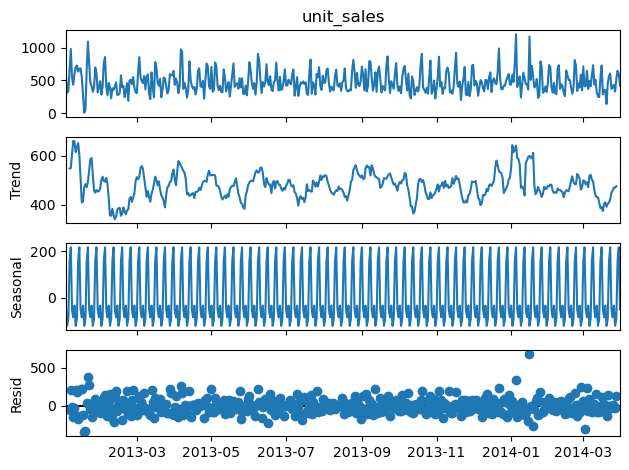

In [102]:
# time series decomposition
decomposition = seasonal_decompose(timeseries_df['unit_sales'], model='additive', period=7)
decomposition.plot()
plt.show()

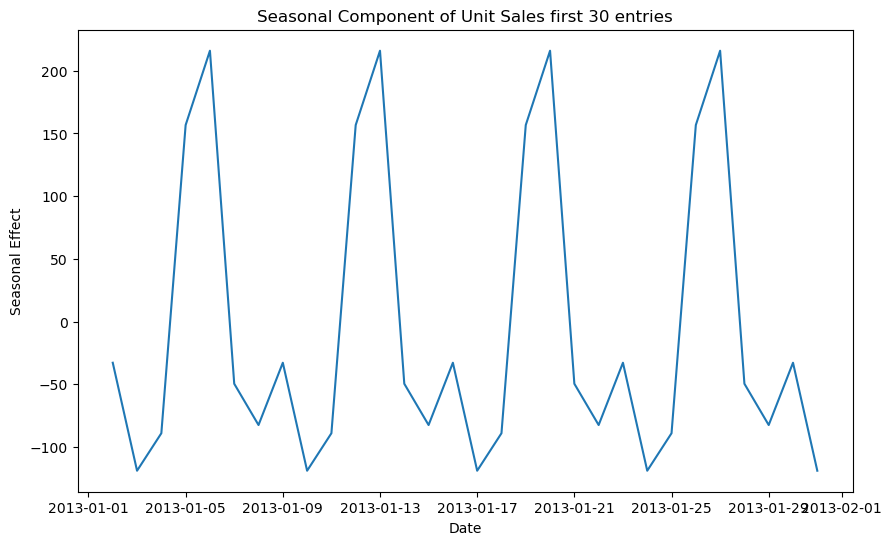

In [103]:
# plot seasonal component
plt.figure(figsize=(10, 6))
sns.lineplot(x=decomposition.seasonal.index[:30], y=decomposition.seasonal.values[:30])
plt.title('Seasonal Component of Unit Sales first 30 entries')
plt.xlabel('Date')
plt.ylabel('Seasonal Effect')
plt.show()

/var/folders/k1/q7h565m92l54zjkrzr_4g5z40000gn/T/ipykernel_87993/2298962297.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)
/var/folders/k1/q7h565m92l54zjkrzr_4g5z40000gn/T/ipykernel_87993/2298962297.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45)


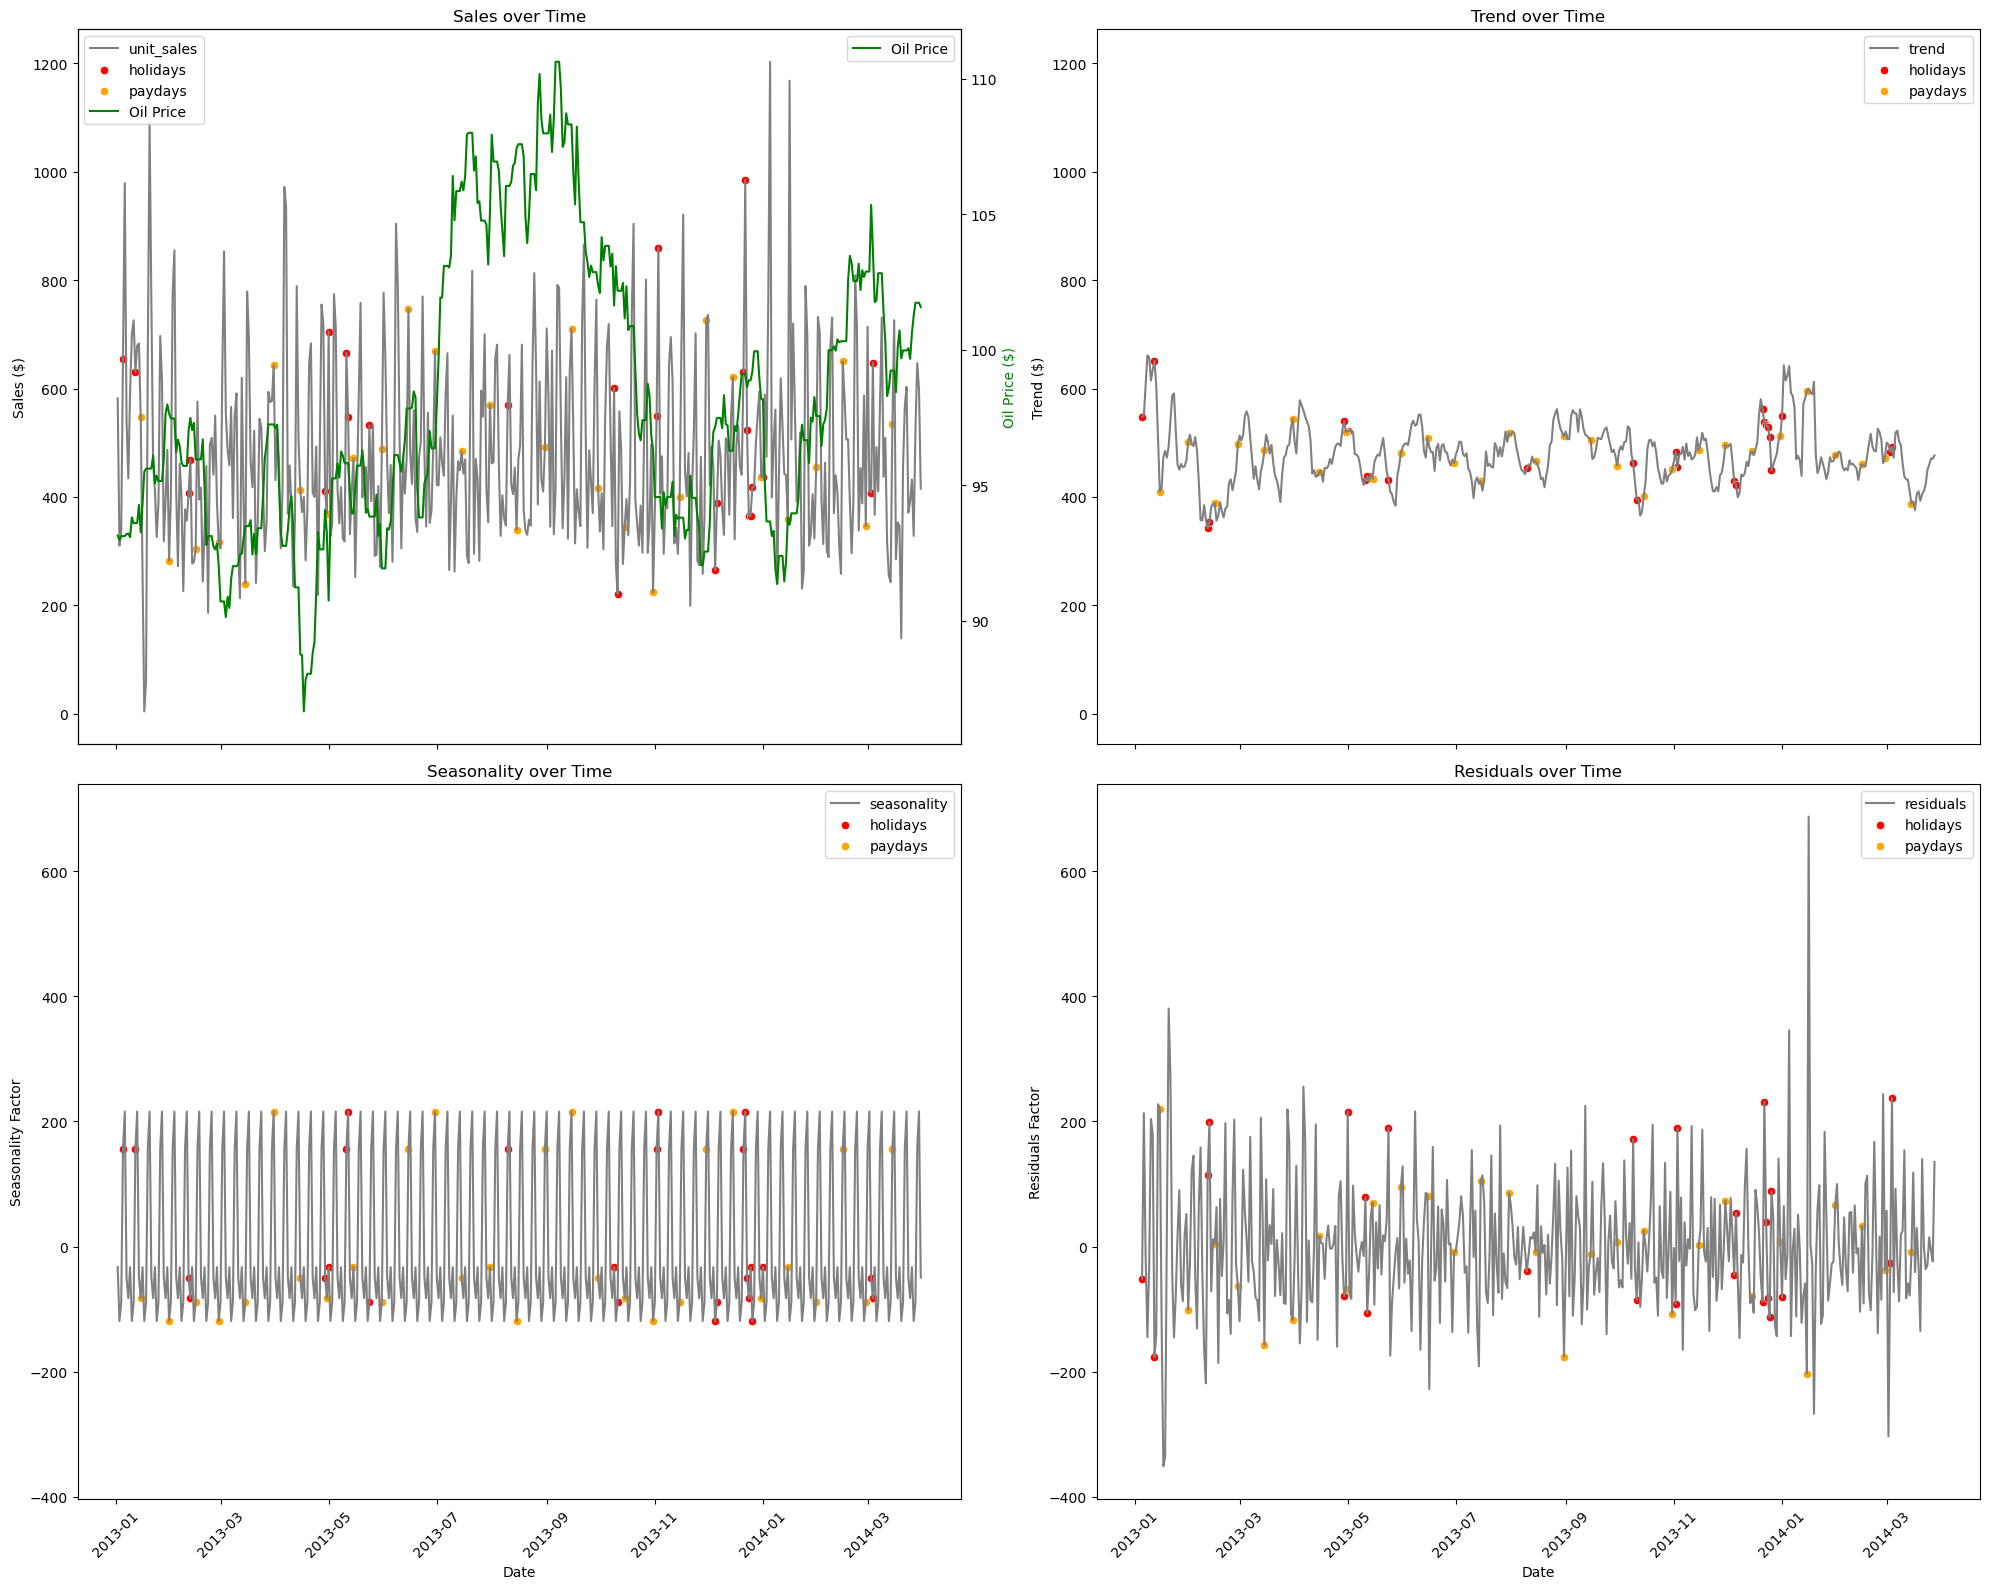

In [104]:
# using seaborn relplot to visualize unit_sales over time while marking holidays and paydays
plot_data = timeseries_df.copy()
plot_data['trend'] = decomposition.trend
plot_data['seasonality'] = decomposition.seasonal
plot_data['residuals'] = decomposition.resid

# Create a grid: 2 rows, 2 column
fig, axes = plt.subplots(2, 2, figsize=(20, 16), sharex=True)

# Link only the top-right Y-axis to the top-left Y-axis
axes[0, 1].sharey(axes[0, 0])
axes[1, 0].sharey(axes[1, 1])

# lot the first line on ax1
sns.lineplot(data=plot_data, x=plot_data.index, y='unit_sales', color='gray', label='unit_sales', ax=axes[0, 0])
sns.scatterplot(data=plot_data[plot_data['is_holiday'] == 1], x=plot_data[plot_data['is_holiday'] == 1].index, y='unit_sales', color='red', label='holidays', ax=axes[0, 0])
sns.scatterplot(data=plot_data[plot_data['is_payday'] == 1], x=plot_data[plot_data['is_payday'] == 1].index, y='unit_sales', color='orange', label='paydays', ax=axes[0, 0])
axes[0, 0].set_ylabel('Sales ($)')
axes[0, 0].set_title('Sales over Time')
ax11 = axes[0, 0].twinx()

# Plot the second line on ax1.1
sns.lineplot(data=plot_data, x=plot_data.index, y='dcoilwtico', ax=ax11, color='green', label='Oil Price')
ax11.set_ylabel('Oil Price ($)', color='green')

# handeling legends for ax1 and ax1.1
lines1, labels1 = axes[0, 0].get_legend_handles_labels()
lines2, labels2 = ax11.get_legend_handles_labels()
axes[0, 0].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Plot the second line on ax2
sns.lineplot(data=plot_data, x=plot_data.index, y='trend', color='gray', label='trend', ax=axes[0, 1])
sns.scatterplot(data=plot_data[plot_data['is_holiday'] == 1], x=plot_data[plot_data['is_holiday'] == 1].index, y='trend', color='red', label='holidays', ax=axes[0, 1])
sns.scatterplot(data=plot_data[plot_data['is_payday'] == 1], x=plot_data[plot_data['is_payday'] == 1].index, y='trend', color='orange', label='paydays', ax=axes[0, 1])
axes[0, 1].set_ylabel('Trend ($)')
axes[0, 1].set_title('Trend over Time')

# Plot the second line on ax3
sns.lineplot(data=plot_data, x=plot_data.index, y='seasonality', color='gray', label='seasonality', ax=axes[1, 0])
sns.scatterplot(data=plot_data[plot_data['is_holiday'] == 1], x=plot_data[plot_data['is_holiday'] == 1].index, y='seasonality', color='red', label='holidays', ax=axes[1, 0])
sns.scatterplot(data=plot_data[plot_data['is_payday'] == 1], x=plot_data[plot_data['is_payday'] == 1].index, y='seasonality', color='orange', label='paydays', ax=axes[1, 0])
axes[1, 0].set_ylabel('Seasonality Factor')
axes[1, 0].set_title('Seasonality over Time')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

# Plot the second line on ax4
sns.lineplot(data=plot_data, x=plot_data.index, y='residuals', color='gray', label='residuals', ax=axes[1, 1])
sns.scatterplot(data=plot_data[plot_data['is_holiday'] == 1], x=plot_data[plot_data['is_holiday'] == 1].index, y='residuals', color='red', label='holidays', ax=axes[1, 1])
sns.scatterplot(data=plot_data[plot_data['is_payday'] == 1], x=plot_data[plot_data['is_payday'] == 1].index, y='residuals', color='orange', label='paydays', ax=axes[1, 1])
axes[1, 1].set_ylabel('Residuals Factor')
axes[1, 1].set_title('Residuals over Time')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45)

plt.tight_layout() # Prevents overlap
plt.show()

In [105]:
# correlation between unit_sales and oil price
correlation = plot_data['unit_sales'].corr(plot_data['dcoilwtico'])
print(f"Correlation between unit_sales and oil price: {correlation:.4f}")

Correlation between unit_sales and oil price: 0.0043


> Oil price does not correlate with the sales.

/var/folders/k1/q7h565m92l54zjkrzr_4g5z40000gn/T/ipykernel_87993/2854642315.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Payday', 'Holiday', 'Regular'], y=[mean_payday, mean_holiday, mean_regular], palette=['orange', 'red', 'gray'])


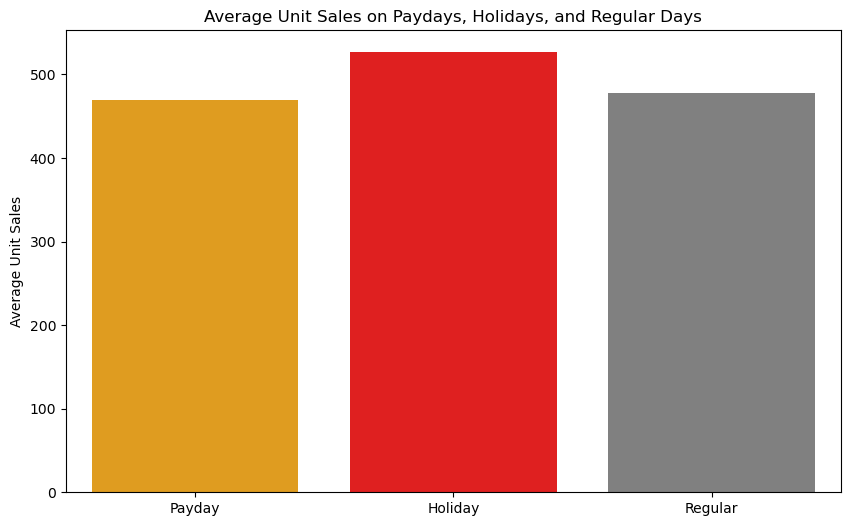

In [106]:
# plot pay day vs holiday vs regualr days
plt.figure(figsize=(10, 6))
mean_payday = plot_data[plot_data['is_payday'] == 1]['unit_sales'].mean()
mean_holiday = plot_data[plot_data['is_holiday'] == 1]['unit_sales'].mean()
mean_regular = plot_data[(plot_data['is_payday'] == 0) & (plot_data['is_holiday'] == 0)]['unit_sales'].mean()
sns.barplot(x=['Payday', 'Holiday', 'Regular'], y=[mean_payday, mean_holiday, mean_regular], palette=['orange', 'red', 'gray'])
plt.title('Average Unit Sales on Paydays, Holidays, and Regular Days')
plt.ylabel('Average Unit Sales')
plt.show()

/var/folders/k1/q7h565m92l54zjkrzr_4g5z40000gn/T/ipykernel_87993/2264822823.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Payday','Day After Payday', 'Day Before Holiday', 'Holiday', 'Regular'], y=[mean_payday,mean_payday_af, mean_holiday_bf, mean_holiday, mean_regular], palette=['red', 'orange', 'lightgreen', 'green', 'gray'])


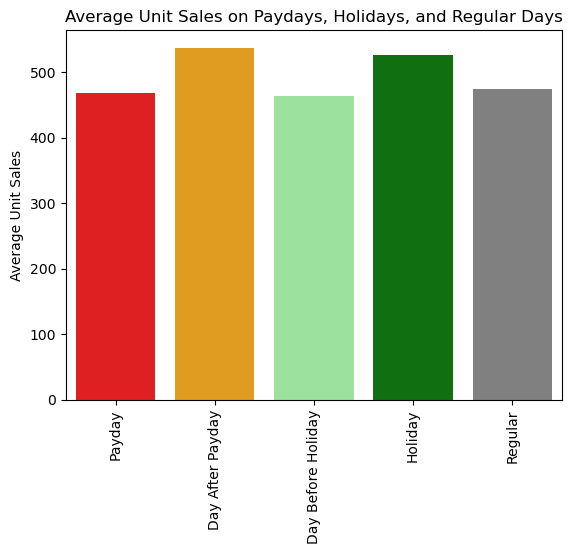

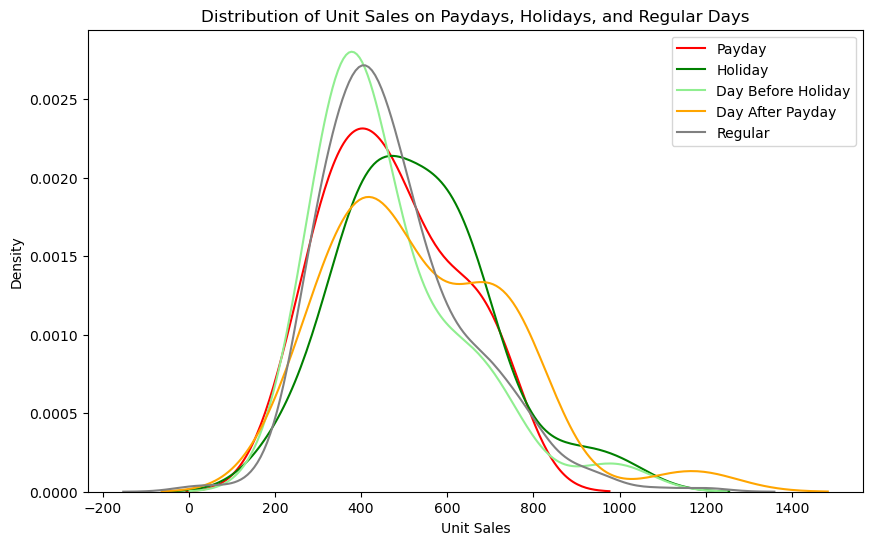

In [107]:
# add one day before hoilday and one day after payday as additional features
plot_data['is_day_before_holiday'] = plot_data['is_holiday'].shift(-1).fillna(0).astype(int)
plot_data['is_day_after_payday'] = plot_data['is_payday'].shift(1).fillna(0).astype(int)

# add mean to plot_data for the new features
mean_holiday_bf = plot_data[plot_data['is_day_before_holiday'] == 1]['unit_sales'].mean()
mean_payday_af = plot_data[plot_data['is_day_after_payday'] == 1]['unit_sales'].mean()
mean_regular = plot_data[(plot_data['is_payday'] == 0) & (plot_data['is_holiday'] == 0) & (plot_data['is_day_before_holiday'] == 0) & (plot_data['is_day_after_payday'] == 0)]['unit_sales'].mean()

sns.barplot(x=['Payday','Day After Payday', 'Day Before Holiday', 'Holiday', 'Regular'], y=[mean_payday,mean_payday_af, mean_holiday_bf, mean_holiday, mean_regular], palette=['red', 'orange', 'lightgreen', 'green', 'gray'])
plt.title('Average Unit Sales on Paydays, Holidays, and Regular Days')
plt.ylabel('Average Unit Sales')
plt.xticks(rotation=90)
plt.show()

# plot eace KDE for payday, holiday, day before holiday, day after payday and regular days
plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_data[plot_data['is_payday'] == 1]['unit_sales'], label='Payday', color='red')
sns.kdeplot(data=plot_data[plot_data['is_holiday'] == 1]['unit_sales'], label='Holiday', color='green')
sns.kdeplot(data=plot_data[plot_data['is_day_before_holiday'] == 1]['unit_sales'], label='Day Before Holiday', color='lightgreen')
sns.kdeplot(data=plot_data[plot_data['is_day_after_payday'] == 1]['unit_sales'], label='Day After Payday', color='orange')
sns.kdeplot(data=plot_data[(plot_data['is_payday'] == 0) & (plot_data['is_holiday'] == 0) & (plot_data['is_day_before_holiday'] == 0) & (plot_data['is_day_after_payday'] == 0)]['unit_sales'], label='Regular', color='gray')
plt.title('Distribution of Unit Sales on Paydays, Holidays, and Regular Days')
plt.xlabel('Unit Sales')
plt.ylabel('Density')
plt.legend()
plt.show()

> It looks like there might be a light effect of sales increasing 1 day after payday and one day before a holiday.

## Correlation of Exogenous Variables

### Linear Relationship via Person Correlation

In [108]:
plot_data.corr()['unit_sales'].sort_values(ascending=False)

unit_sales               1.000000
seasonality              0.713610
is_weekend               0.690498
residuals                0.628969
day_of_week              0.507522
trend                    0.334275
is_day_after_payday      0.088268
is_holiday               0.067757
year                     0.016162
dcoilwtico               0.004278
month                   -0.013832
is_payday               -0.016520
is_day_before_holiday   -0.023995
day                     -0.093487
is_earthquake                 NaN
Name: unit_sales, dtype: float64

> Unit sales correlate with the Day of the Week because of the weekly seasonality

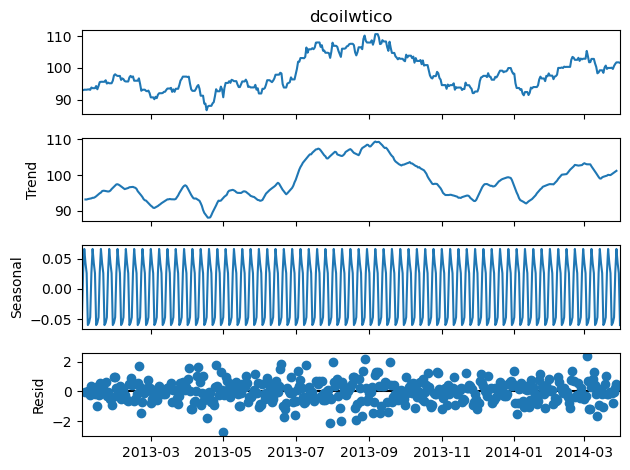

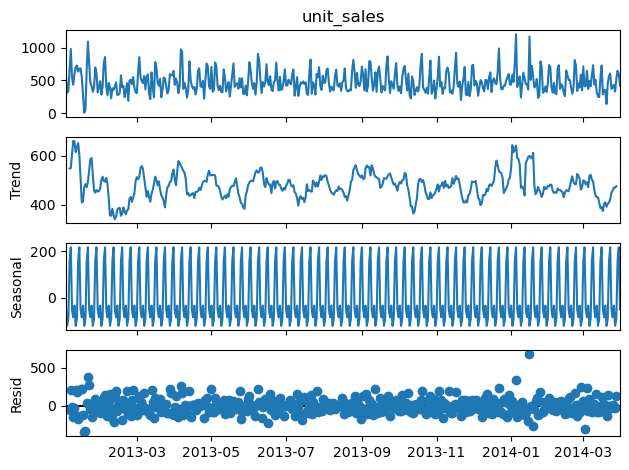

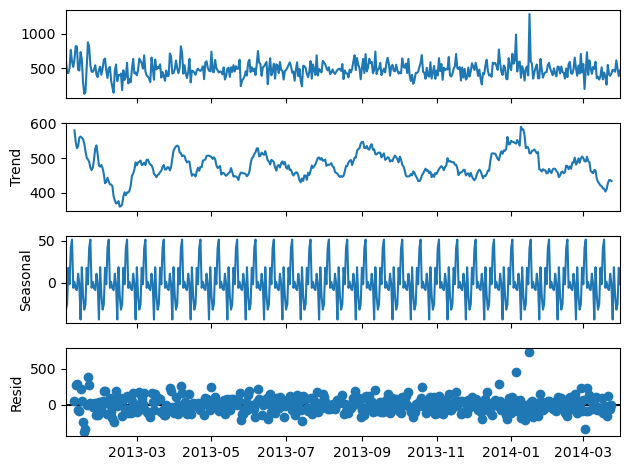

In [119]:
# time series decomposition
decomposition_oil = seasonal_decompose(plot_data['dcoilwtico'], model='additive')
decomposition_oil.plot()
decomposition.plot()
plt.show()

plot_data['trend_oil'] = decomposition_oil.trend
plot_data['seasonality_oil'] = decomposition_oil.seasonal
plot_data['residuals_oil'] = decomposition_oil.resid


plot_data.corr()['unit_sales'].sort_values(ascending=False)

# removing weekly seasonality from unit_sales
temp = plot_data['unit_sales'] - plot_data['seasonality']
decomposition_temp = seasonal_decompose(temp, model='additive', period=15)
decomposition_temp.plot()
plt.show()

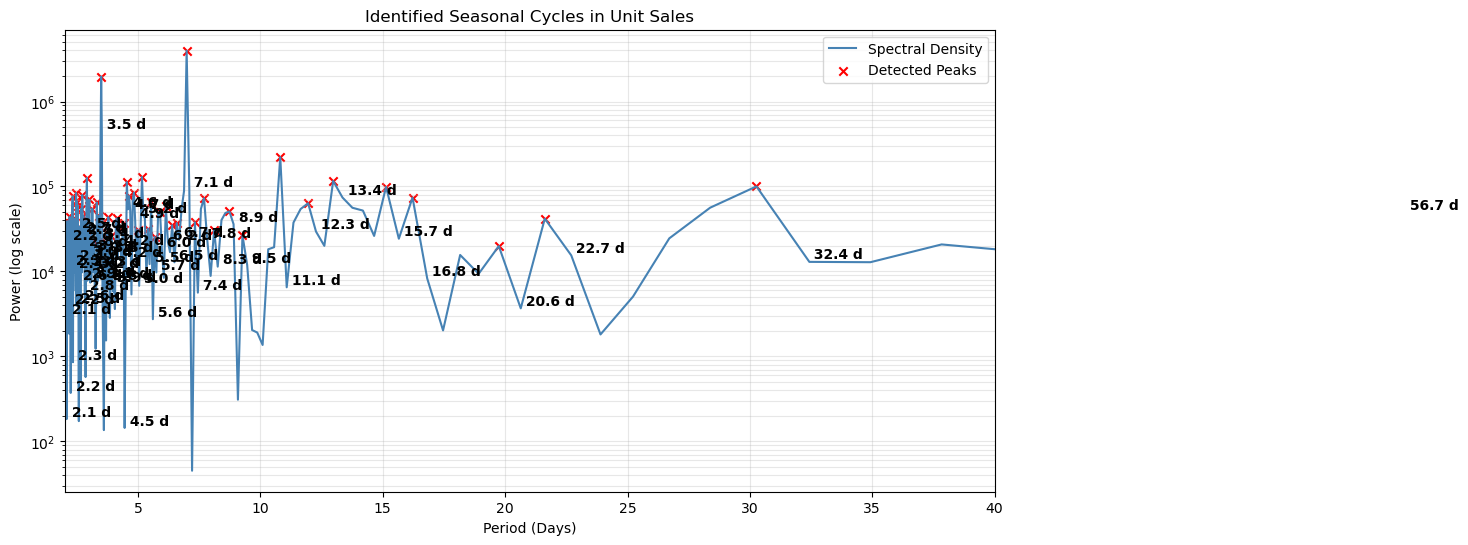

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram, find_peaks

# 1. Compute Periodogram
fs = 1 
f, Pxx_den = periodogram(plot_data['unit_sales'], fs)

# 2. Convert to Period (skip f=0)
periods = 1 / f[1:]
power = Pxx_den[1:]

# 3. Find Peaks
# 'prominence' filters out tiny local jitters; adjust it if you miss peaks
peaks, properties = find_peaks(power, prominence=10**4) 

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.semilogy(periods, power, color='steelblue', label='Spectral Density')
plt.scatter(periods[peaks], power[peaks], color='red', marker='x', label='Detected Peaks')

# 5. Annotate the top peaks
for i in peaks:
    # Only label peaks within a reasonable range (e.g., 2 to 60 days)
    if 2 <= periods[i-1] <= 60:
        plt.text(periods[i-1], power[i-1], f' {periods[i-1]:.1f} d', 
                 fontsize=10, verticalalignment='bottom', fontweight='bold')

plt.xlim(2, 40) # Zoom in on the most common business cycles
plt.xlabel('Period (Days)')
plt.ylabel('Power (log scale)')
plt.title('Identified Seasonal Cycles in Unit Sales')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

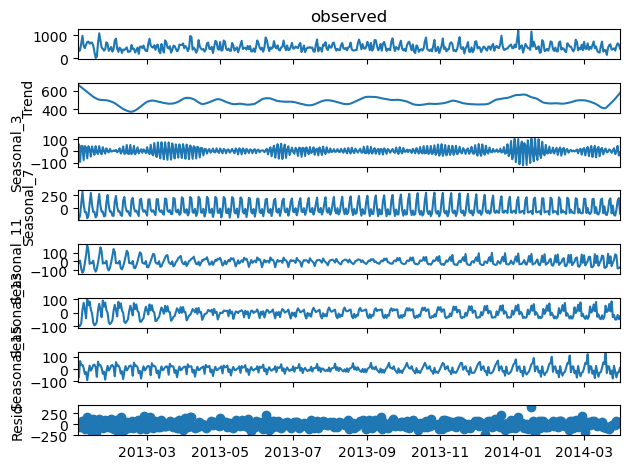

Mean of seasonality 3-day cycle: 0.06
Mean of seasonality 7-day cycle: -0.19
Mean of seasonality 11-day cycle: -0.52
Mean of seasonality 13-day cycle: -0.63
Mean of seasonality 15-day cycle: -0.29


In [140]:
from statsmodels.tsa.seasonal import MSTL

# If your data is hourly, you might have daily (24) and weekly (168) cycles
mstl = MSTL(plot_data['unit_sales'], periods=(3, 7, 11, 13, 15))
res = mstl.fit()

res.plot()
plt.show()

print(f"Mean of seasonality 3-day cycle: {res.seasonal.seasonal_3.mean():.2f}")
print(f"Mean of seasonality 7-day cycle: {res.seasonal.seasonal_7.mean():.2f}")
print(f"Mean of seasonality 11-day cycle: {res.seasonal.seasonal_11.mean():.2f}")
print(f"Mean of seasonality 13-day cycle: {res.seasonal.seasonal_13.mean():.2f}")
print(f"Mean of seasonality 15-day cycle: {res.seasonal.seasonal_15.mean():.2f}")

### Spearman Rank Correlation

Useful for non-linear but "ordered" relationships (e.g., as temperature increases, ice cream sales increase, but not at a constant rate).

In [110]:
print("Spearman Rank Correlation of Features with Unit Sales:")
plot_data.corr(method='spearman')['unit_sales'].sort_values(ascending=False)

Spearman Rank Correlation of Features with Unit Sales:


unit_sales               1.000000
is_weekend               0.678494
seasonality              0.668333
residuals                0.576136
day_of_week              0.476929
trend                    0.317600
seasonality_oil          0.099220
is_holiday               0.075515
is_day_after_payday      0.071479
residuals_oil            0.028578
year                     0.004785
trend_oil               -0.004294
dcoilwtico              -0.004547
month                   -0.004930
is_payday               -0.007388
is_day_before_holiday   -0.039783
day                     -0.079395
is_earthquake                 NaN
Name: unit_sales, dtype: float64

### Granger Causality Test

A statistical test to determine if one time series is useful in forecasting another. It asks: "Does knowing the past of X help predict the future of Y better than just knowing the past of Y alone?"

In [113]:
def grangercausalitytests_df(df, target_col, max_lag=6):
    """"We test if 'marketing_spend' (X) granger-causes 'sales' (Y)
    """
    from statsmodels.tsa.stattools import grangercausalitytests
    # Data must be a 2D array/DataFrame with [Target, Driver]
    columns = df.columns
    columns = columns.drop(target_col)
    results_dict = {}
    if len(columns) == 0:
        raise ValueError(f"No columns left in DataFrame after dropping target column '{target_col}'.")
    for col in columns:
        try:
            data = df[[target_col, col]].diff().dropna()
            # maxlag: how many days/weeks back should we look for a relationship?
            results = grangercausalitytests(data, maxlag=max_lag, verbose=False)
            for lag in range(1, max_lag + 1):
                threshold = 0.05
                ssr_ftest = results[lag][0]['ssr_ftest'][1]
                ssr_chi2test = results[lag][0]['ssr_chi2test'][1]
                lrtest = results[lag][0]['lrtest'][1]
                params_ftest = results[lag][0]['params_ftest'][1]
                if ssr_ftest < threshold and ssr_chi2test < threshold and lrtest < threshold and params_ftest < threshold:
                    print(f"Granger causality test for '{col}' causing '{target_col}' at lag {lag}: p-value = {ssr_chi2test:.4f} (significant)")
                else:
                    continue
            results_dict[col] = results
        except Exception as e:
            print(f"Error testing granger causality between '{target_col}' and '{col}': {e}")
    return results_dict

test = grangercausalitytests_df(plot_data, target_col='unit_sales', max_lag=6)

Granger causality test for 'year' causing 'unit_sales' at lag 4: p-value = 0.0216 (significant)
Granger causality test for 'year' causing 'unit_sales' at lag 5: p-value = 0.0009 (significant)
Granger causality test for 'year' causing 'unit_sales' at lag 6: p-value = 0.0002 (significant)
Granger causality test for 'month' causing 'unit_sales' at lag 4: p-value = 0.0124 (significant)
Granger causality test for 'month' causing 'unit_sales' at lag 5: p-value = 0.0008 (significant)
Granger causality test for 'month' causing 'unit_sales' at lag 6: p-value = 0.0004 (significant)
Granger causality test for 'day_of_week' causing 'unit_sales' at lag 1: p-value = 0.0000 (significant)
Granger causality test for 'day_of_week' causing 'unit_sales' at lag 2: p-value = 0.0000 (significant)
Granger causality test for 'day_of_week' causing 'unit_sales' at lag 3: p-value = 0.0000 (significant)
Granger causality test for 'day_of_week' causing 'unit_sales' at lag 4: p-value = 0.0000 (significant)
Granger c

/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/timeseries_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarn

year:
- Granger causality test for 'year' causing 'unit_sales' at lag 4: p-value = 0.0216 (significant)
- Granger causality test for 'year' causing 'unit_sales' at lag 5: p-value = 0.0009 (significant)
- Granger causality test for 'year' causing 'unit_sales' at lag 6: p-value = 0.0002 (significant)

month:
- Granger causality test for 'month' causing 'unit_sales' at lag 4: p-value = 0.0124 (significant)
- Granger causality test for 'month' causing 'unit_sales' at lag 5: p-value = 0.0008 (significant)
- Granger causality test for 'month' causing 'unit_sales' at lag 6: p-value = 0.0004 (significant)

day of the week:
- Granger causality test for 'day_of_week' causing 'unit_sales' at lag 1: p-value = 0.0000 (significant)
- Granger causality test for 'day_of_week' causing 'unit_sales' at lag 2: p-value = 0.0000 (significant)
- Granger causality test for 'day_of_week' causing 'unit_sales' at lag 3: p-value = 0.0000 (significant)
- Granger causality test for 'day_of_week' causing 'unit_sales' at lag 4: p-value = 0.0000 (significant)
- Granger causality test for 'day_of_week' causing 'unit_sales' at lag 5: p-value = 0.0000 (significant)
- Granger causality test for 'day_of_week' causing 'unit_sales' at lag 6: p-value = 0.0000 (significant)

is_weekend:
- Granger causality test for 'is_weekend' causing 'unit_sales' at lag 1: p-value = 0.0000 (significant)
- Granger causality test for 'is_weekend' causing 'unit_sales' at lag 2: p-value = 0.0000 (significant)
- Granger causality test for 'is_weekend' causing 'unit_sales' at lag 3: p-value = 0.0000 (significant)
- Granger causality test for 'is_weekend' causing 'unit_sales' at lag 4: p-value = 0.0000 (significant)
- Granger causality test for 'is_weekend' causing 'unit_sales' at lag 5: p-value = 0.0000 (significant)
- Granger causality test for 'is_weekend' causing 'unit_sales' at lag 6: p-value = 0.0000 (significant)

pay day:
- Granger causality test for 'is_payday' causing 'unit_sales' at lag 1: p-value = 0.0408 (significant)

seasonality of oil:
- Granger causality test for 'seasonality_oil' causing 'unit_sales' at lag 1: p-value = 0.0000 (significant)
- Granger causality test for 'seasonality_oil' causing 'unit_sales' at lag 2: p-value = 0.0000 (significant)
- Granger causality test for 'seasonality_oil' causing 'unit_sales' at lag 3: p-value = 0.0000 (significant)
- Granger causality test for 'seasonality_oil' causing 'unit_sales' at lag 4: p-value = 0.0000 (significant)
- Granger causality test for 'seasonality_oil' causing 'unit_sales' at lag 5: p-value = 0.0000 (significant)
- Granger causality test for 'seasonality_oil' causing 'unit_sales' at lag 6: p-value = 0.0000 (significant)





## Autocorrelation and Partial Autocorrelation

In the following we are investigating the Autocorrelation plots.

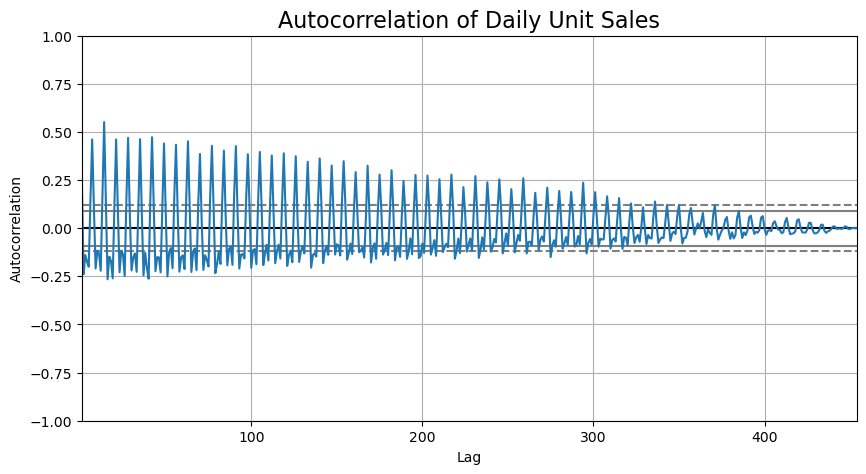

In [348]:
# Plot autocorrelation
plt.figure(figsize=(10, 5))
autocorrelation_plot(timeseries_df['unit_sales'])
plt.title('Autocorrelation of Daily Unit Sales', fontsize=16)
plt.show()


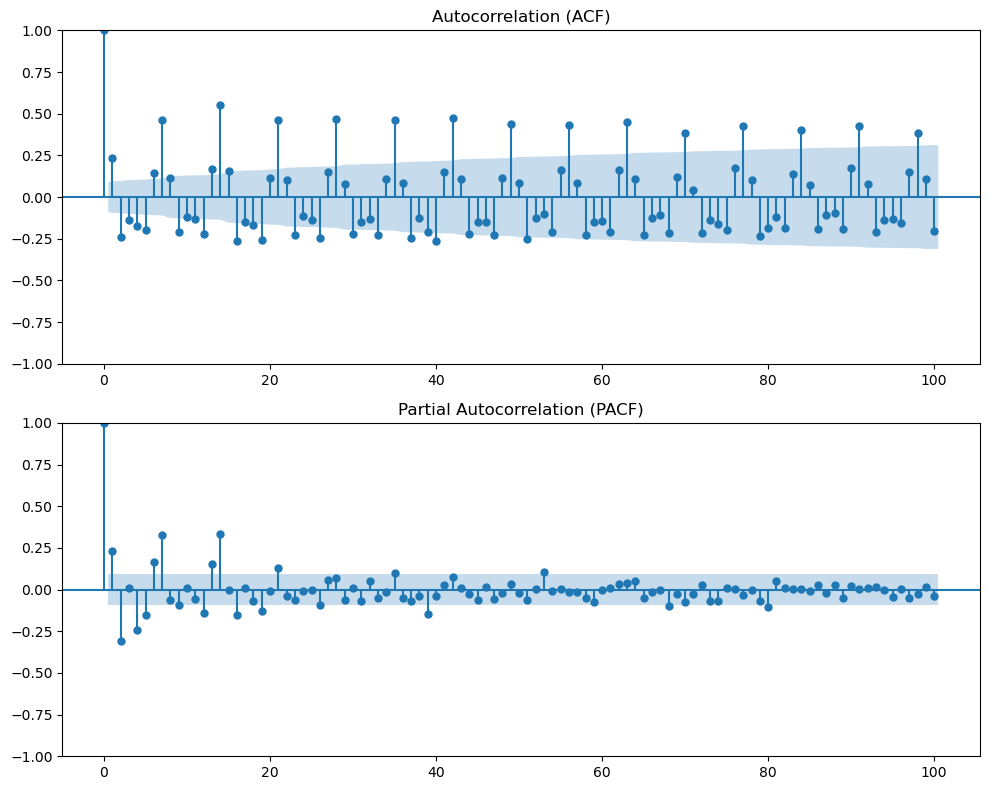

In [349]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot ACF: Good for identifying Moving Average (MA) processes
plot_acf(plot_data['unit_sales'].dropna(), ax=ax1, lags=100)
ax1.set_title('Autocorrelation (ACF)')

# Plot PACF: Good for identifying Autoregressive (AR) processes
plot_pacf(plot_data['unit_sales'].dropna(), ax=ax2, lags=100, method='ywm')
ax2.set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

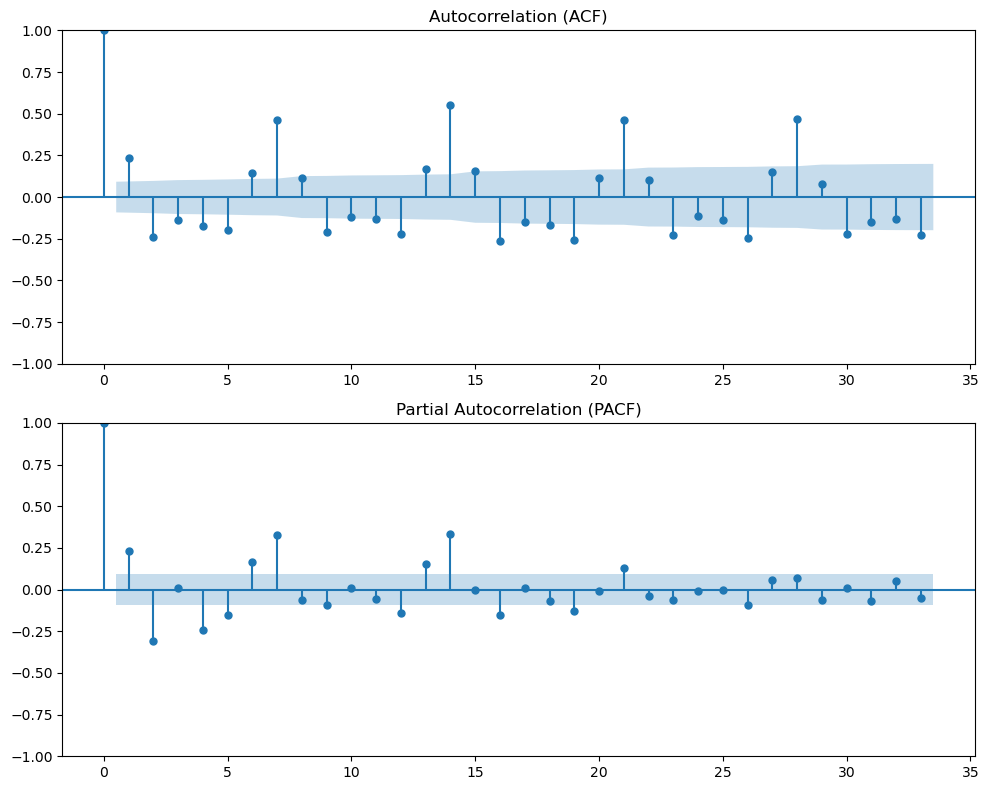

In [141]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot ACF: Good for identifying Moving Average (MA) processes
plot_acf(plot_data['unit_sales'].dropna(), ax=ax1, lags=33)
ax1.set_title('Autocorrelation (ACF)')

# Plot PACF: Good for identifying Autoregressive (AR) processes
plot_pacf(plot_data['unit_sales'].dropna(), ax=ax2, lags=33, method='ywm')
ax2.set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

- **Period: (P)**
    The period looks to be 7. As we can see in the ACF plot.

- **P

## Stationarity

In the following we are investigation stationarity.

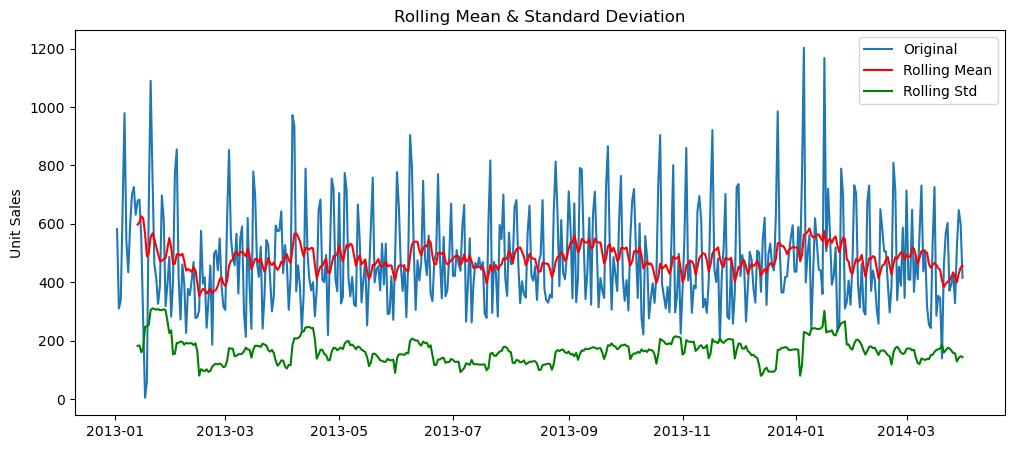

In [351]:
rolling_mean = timeseries_df['unit_sales'].rolling(window=12).mean()
rolling_std = timeseries_df['unit_sales'].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(timeseries_df['unit_sales'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean', color='red')
plt.plot(rolling_std, label='Rolling Std', color='green')
plt.title('Rolling Mean & Standard Deviation')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()


In [352]:
result = adfuller(timeseries_df['unit_sales'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print(f"The time series is {'stationary' if result[1] < 0.05 else 'non-stationary'} based on the ADF test.")

ADF Statistic: -5.051243167393025
p-value: 1.7554305139624233e-05
The time series is stationary based on the ADF test.


The ADF test checks for the presence of a unit root, which would indicate that the series is non-stationary.

>Null hypothesis (H₀): The series has a unit root → non-stationary

>Alternative hypothesis (H₁): The series is stationary

Result Interpretation:
- If p-value < 0.05, the series is stationary (good for modeling).
- If p-value > 0.05, the series is non-stationary — and it’s important because many forecasting models require stationary inputs (e.g. ARIMA). 

## Write df to data

In [353]:
timeseries_df.to_csv("../data/procesed/timeseries_ABT.csv")